# Royal Caribbean — Pricing Optimization (Orchestrator)

This notebook **only orchestrates**. All logic lives in `src/`:

| Stage | Module | Class |
|---|---|---|
| 1. Load + DQ | `src/data_loader.py` | `DataLoader` |
| 2. EDA | `src/eda.py` | `EDAExplorer` |
| 3. Feature engineering | `src/feature_engineering.py` | `FeatureEngineer` |
| 4. Temporal split | `src/splitter.py` | `TemporalSplitter` |
| 5. Model training | `src/models.py` | `ModelZoo`, `ModelTrainer` |
| 6. Evaluation + winner pick | `src/evaluator.py` | `Evaluator` |
| 7–9. Diagnostics | `src/visualizer.py` | `ResultsVisualizer` |

**Assumptions flagged for the case:**
- `revenue` is dropped from features (function of price → leakage).
- `competitor_price` is observable at booking time.
- Outliers kept (luxury Suite prices are real signal).
- Lag NaNs filled with route×cabin median (avoids shrinking train).

In [1]:
# Make src/ importable when the notebook is run from the notebooks/ folder.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

In [2]:
from src import (
    DataLoader,
    EDAExplorer,
    FeatureEngineer,
    TemporalSplitter,
    ModelZoo,
    ModelTrainer,
    Evaluator,
    ResultsVisualizer,
)

## 1. Data Loading & Initial Exploration

In [3]:
loader = DataLoader(PROJECT_ROOT / "data" / "bookings.csv")
df = loader.load()
print(loader.quality_report())
df.head()

DataQualityReport(shape=(5000, 10), duplicates=0)
missing:
  (none)


,booking_date,sail_date,route,cabin_type,price,occupancy_rate,days_to_sail,competitor_price,is_holiday,revenue
0,2023-04-25,2023-05-02,Miami-Jamaica,Ocean View,748.61,0.69,7,792.67,0,55786.42
1,2023-05-23,2023-06-19,Tampa-Cozumel,Interior,605.79,0.83,27,609.40,1,77934.88
2,2024-03-08,2024-03-17,Miami-Nassau,Interior,729.87,0.93,9,723.91,1,72629.36
3,2023-08-27,2024-01-04,Tampa-Cozumel,Interior,507.09,0.80,130,503.06,1,61256.47
4,2023-07-23,2024-01-06,Tampa-Cozumel,Suite,1651.36,0.51,167,1513.48,0,90956.91


In [4]:
loader.describe()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_date,5000,548,2024-01-15,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sail_date,5000,684,2023-07-02,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,5000,5,Port Canaveral-Bahamas,1022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cabin_type,5000,4,Interior,1268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,5000.0,NaN,NaN,NaN,997.519932,611.047652,280.94,524.32,795.53,1409.16,3071.23
occupancy_rate,5000.0,NaN,NaN,NaN,0.749764,0.121656,0.32,0.66,0.75,0.84,1.0
days_to_sail,5000.0,NaN,NaN,NaN,89.7324,52.259432,1.0,44.0,88.0,136.0,180.0
competitor_price,5000.0,NaN,NaN,NaN,1016.533292,624.694133,272.31,531.0975,807.155,1433.4225,3533.41
is_holiday,5000.0,NaN,NaN,NaN,0.337,0.472732,0.0,0.0,0.0,1.0,1.0
revenue,5000.0,NaN,NaN,NaN,106722.607146,79417.634396,10795.14,50260.3075,81151.94,138495.605,548684.74


## 2. Exploratory Data Analysis

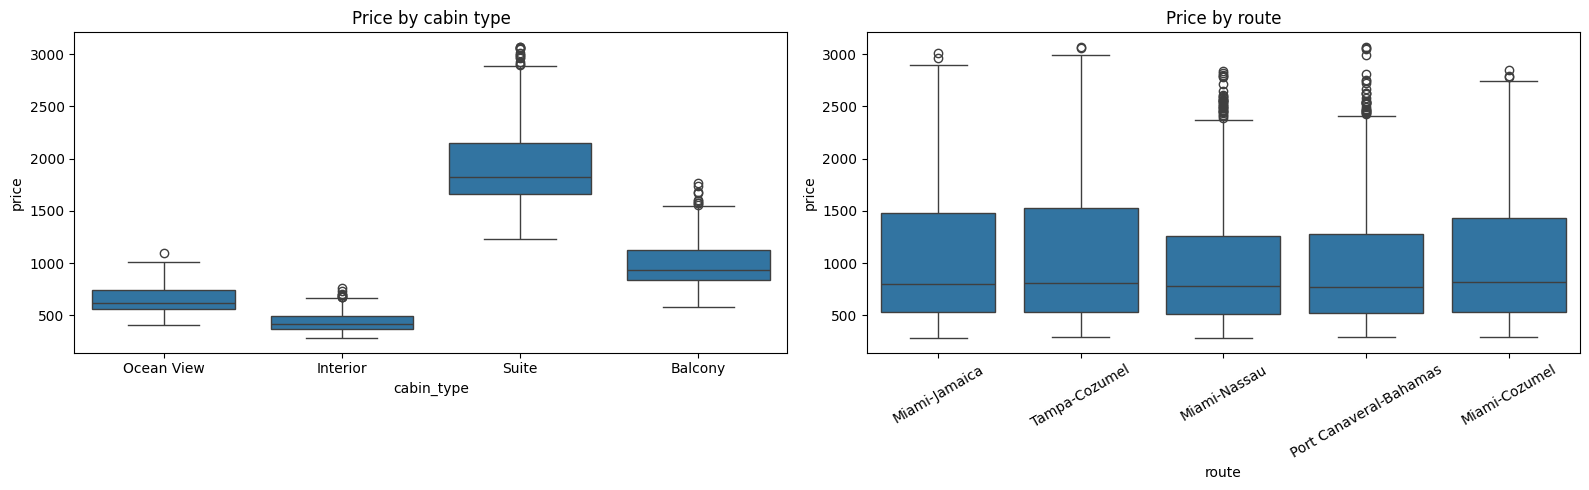

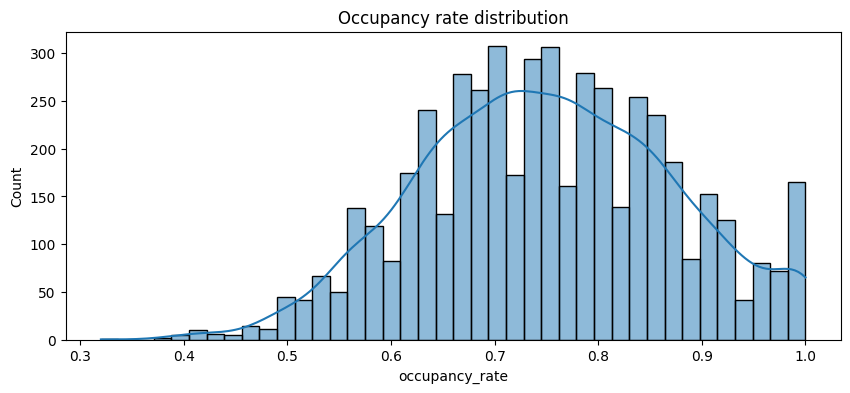

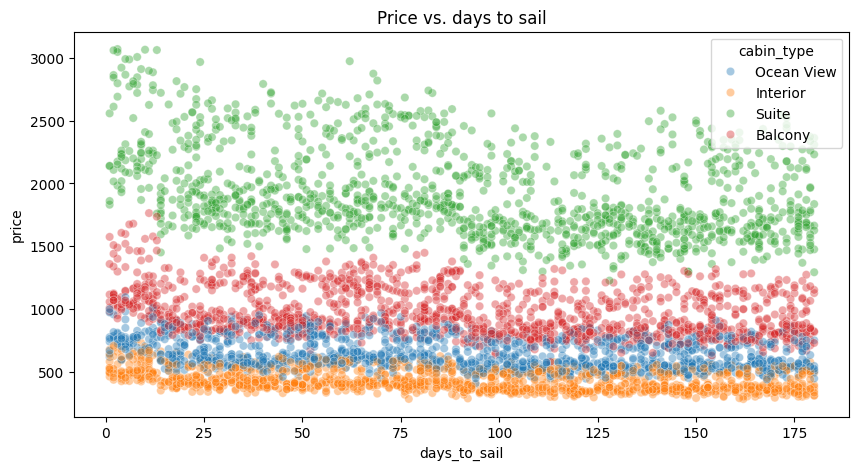

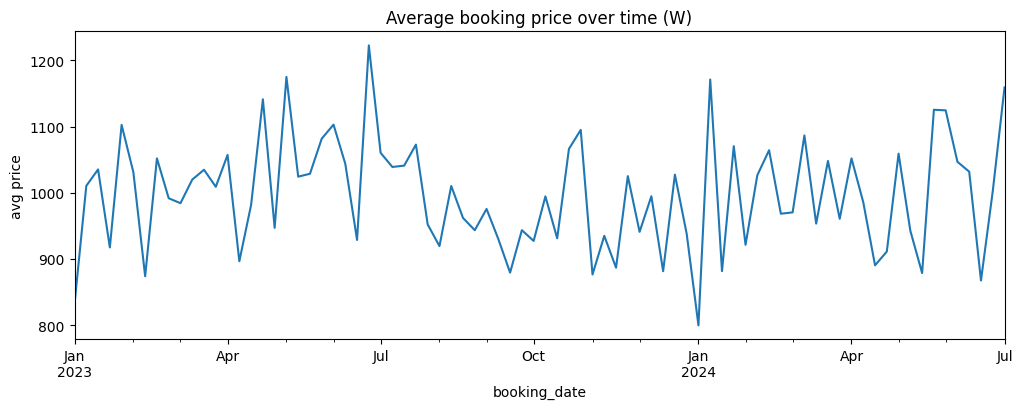

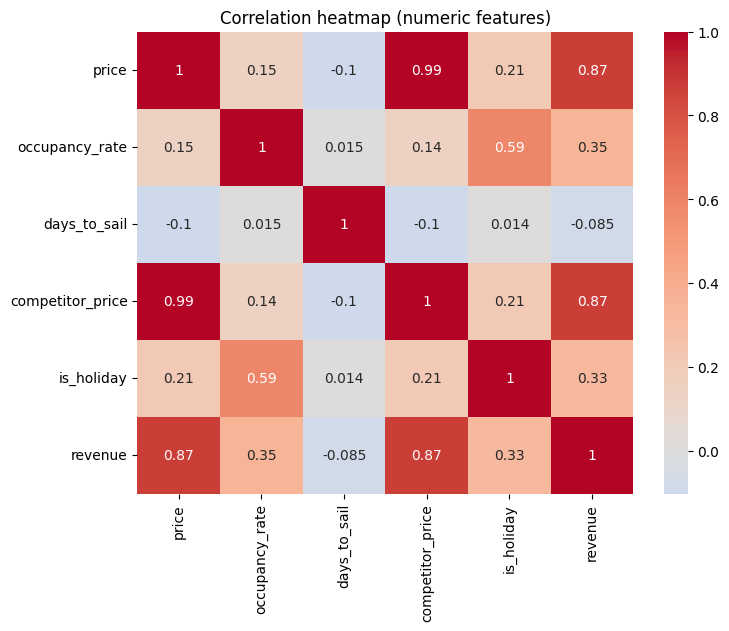

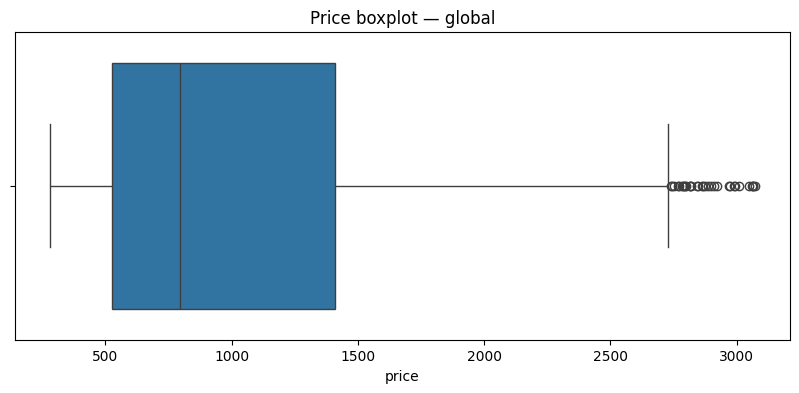

Price IQR outliers: 32 (0.64%)


In [5]:
EDAExplorer(df).run_all()

## 3. Feature Engineering

`FeatureEngineer.transform` chains: date casting → calendar parts → lead-time bucket → grouped lags (with median fill) → one-hot encoding → sort by booking_date.

In [6]:
fe = FeatureEngineer()
df_features = fe.transform(df)
print(f"feature matrix shape: {df_features.shape}")
df_features.head()

feature matrix shape: (5000, 28)


,booking_date,sail_date,price,occupancy_rate,days_to_sail,competitor_price,is_holiday,revenue,booking_month,sail_month,...,route_Miami-Nassau,route_Port Canaveral-Bahamas,route_Tampa-Cozumel,cabin_type_Balcony,cabin_type_Interior,cabin_type_Ocean View,cabin_type_Suite,lead_time_bucket_advance,lead_time_bucket_last_minute,lead_time_bucket_short
0,2023-01-01,2023-03-06,432.21,0.64,64,431.57,0,40385.70,1,3,...,False,False,False,False,True,False,False,True,False,False
1,2023-01-01,2023-06-14,1685.57,0.63,164,1938.24,0,183710.27,1,6,...,False,False,True,False,False,False,True,True,False,False
2,2023-01-01,2023-03-22,1762.07,0.67,80,1853.44,0,230214.45,1,3,...,False,True,False,False,False,False,True,True,False,False
3,2023-01-01,2023-03-25,442.70,0.63,83,481.79,0,27053.40,1,3,...,True,False,False,False,True,False,False,True,False,False
4,2023-01-01,2023-05-29,349.67,0.55,148,352.45,0,16924.03,1,5,...,True,False,False,False,True,False,False,True,False,False


## 4. Temporal Train / Validation / Test Split

In [7]:
splitter = TemporalSplitter(train_months=12, val_months=3, target="price")
split = splitter.split(df_features)
split.shapes()

{'train': (3302, 24), 'val': (874, 24), 'test': (824, 24)}

## 5. Model Training — 4 Candidates

In [8]:
trainer = ModelTrainer(ModelZoo.default_models())
trainer.fit(split.X_train, split.y_train)

trained: LinearRegression


trained: RandomForest


trained: XGBoost


trained: GradientBoosting


{'LinearRegression': LinearRegression(),
 'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...),
 'GradientBoosting': GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)}

## 6. Validation Evaluation & Winner Selection

In [9]:
evaluator = Evaluator()
val_predictions = trainer.predict(split.X_val)
leaderboard = evaluator.evaluate_all(val_predictions, split.y_val)
leaderboard

,RMSE,MAPE,R2
GradientBoosting,57.399858,0.040778,0.990437
XGBoost,59.223733,0.040597,0.989820
LinearRegression,59.349580,0.042268,0.989776
RandomForest,61.153967,0.041713,0.989145


In [10]:
winner_name, wins = evaluator.select_winner(leaderboard)
print("Validation wins per model:")
print(wins)
print(f"\nSelected winner: {winner_name}")
winner_model = trainer.get(winner_name)

Validation wins per model:
                   RMSE   MAPE     R2  total_wins
GradientBoosting   True  False   True           2
XGBoost           False   True  False           1
LinearRegression  False  False  False           0
RandomForest      False  False  False           0

Selected winner: GradientBoosting


## 7. Final Evaluation on the Test Set

In [11]:
test_metrics = evaluator.score(split.y_test, winner_model.predict(split.X_test))
print(f"Final {winner_name} performance on test set:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Final GradientBoosting performance on test set:
  RMSE: 65.4968
  MAPE: 0.0418
  R2: 0.9885


## 8. Diagnostics — Feature Importance, Residuals, Cabin Breakdown

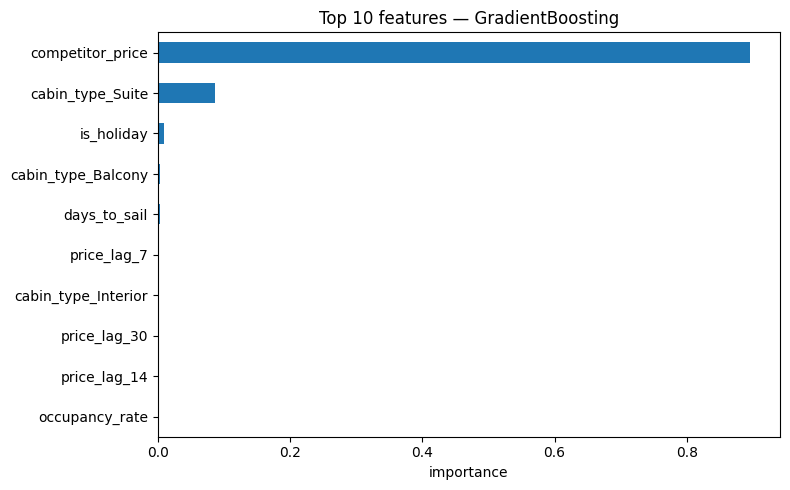

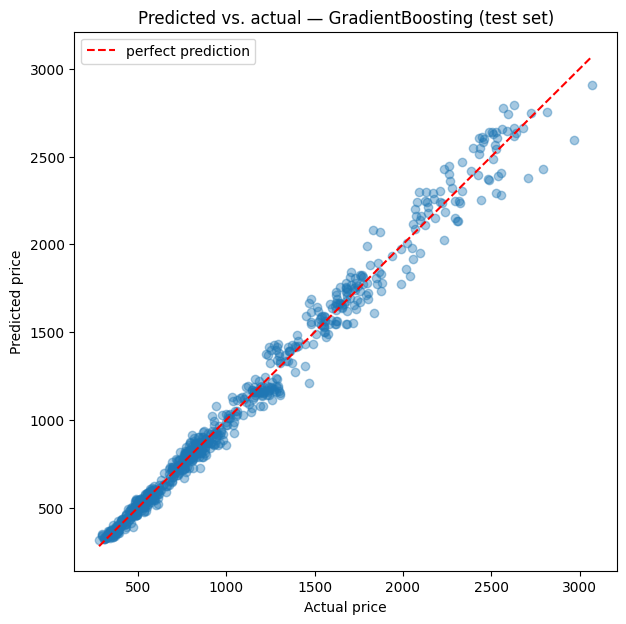

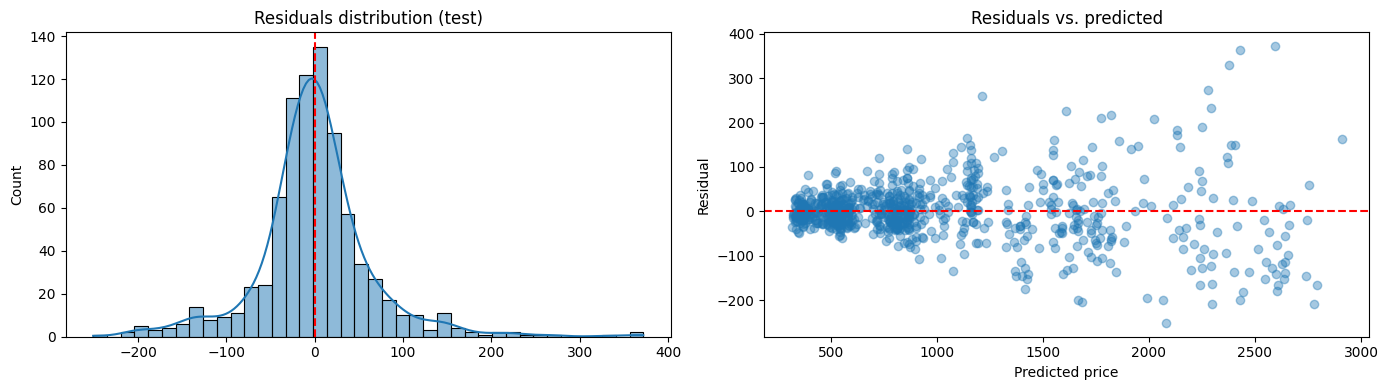

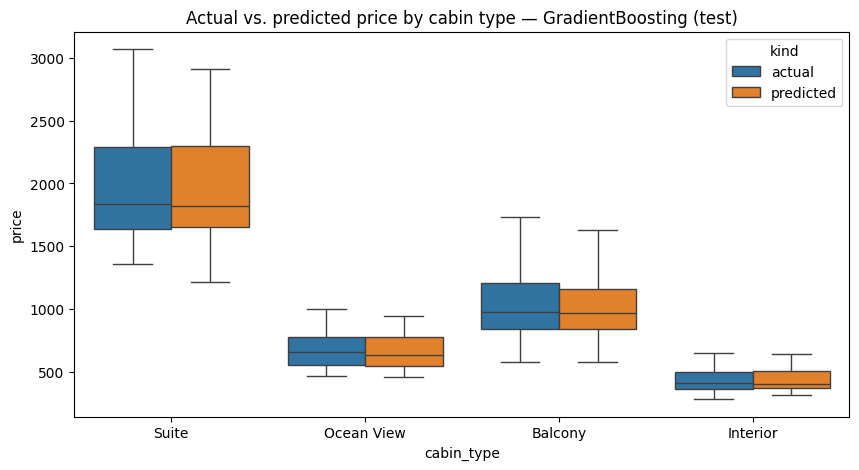

competitor_price       0.896041
cabin_type_Suite       0.085753
is_holiday             0.008824
cabin_type_Balcony     0.002899
days_to_sail           0.002512
price_lag_7            0.001650
cabin_type_Interior    0.000639
price_lag_30           0.000507
price_lag_14           0.000372
occupancy_rate         0.000277
dtype: float64

In [12]:
viz = ResultsVisualizer(
    model=winner_model,
    model_name=winner_name,
    X_test=split.X_test,
    y_test=split.y_test,
    df_test_encoded=df_features.loc[split.test_mask],
)
top10 = viz.run_all(top_n=10)
top10

## Summary

- The pipeline is fully encapsulated in `src/`; the notebook is a 12-cell orchestrator.
- Each class has one responsibility, making the modules independently testable.
- Swapping any stage (e.g. trying a new model set, a different lag schedule, or a different split) means editing a single class — the orchestrator stays untouched.

**Next steps for production:**
- Add unit tests under `tests/` for each module (especially the lag logic in `FeatureEngineer`).
- Hyperparameter search inside `ModelTrainer` using the validation window.
- Wrap the full pipeline in a `Pipeline` class that takes a config and returns trained model + metrics — useful for experiment tracking.